In [1]:
import pandas as pd 
df=pd.read_csv("dataset.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 4424, Columns: 35


In [3]:
info_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values
})
display(info_df)

,Column Name,Data Type,Non-Null Count
0,Marital status,int64,4424
1,Application mode,int64,4424
2,Application order,int64,4424
3,Course,int64,4424
4,Daytime/evening attendance,int64,4424
5,Previous qualification,int64,4424
6,Nacionality,int64,4424
7,Mother's qualification,int64,4424
8,Father's qualification,int64,4424
9,Mother's occupation,int64,4424


In [4]:
target_counts = df['Target'].value_counts()
target_percentage = df['Target'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_percentage.round(2)
})
display(target_summary)

,Count,Percentage (%)
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


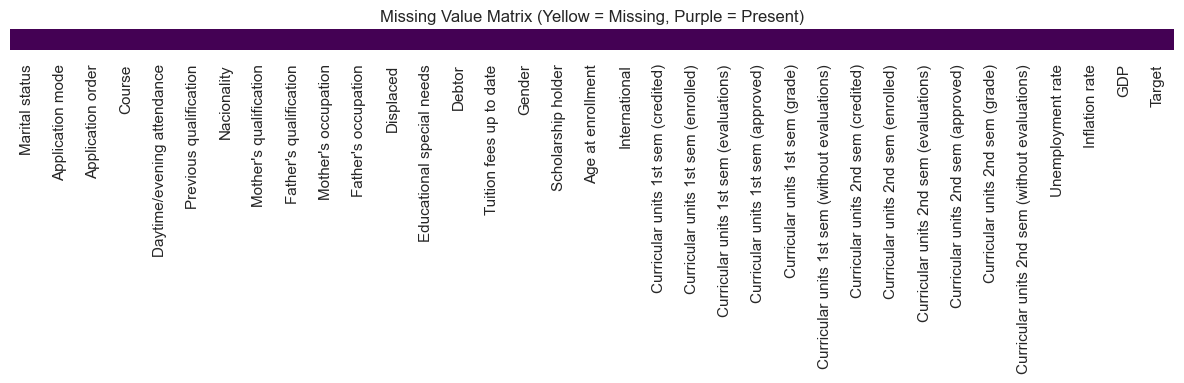

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Value Matrix (Yellow = Missing, Purple = Present)")
plt.tight_layout()
plt.show()

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Count: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Dropped duplicate records.")
anomaly_mask = (df['Curricular units 1st sem (enrolled)'] == 0) & (df['Curricular units 1st sem (approved)'] > 0)
print(f"Logical Academic Anomalies Detected: {anomaly_mask.sum()}")

if anomaly_mask.sum() > 0:
    df = df[anomaly_mask]
    print("Removed anomalous academic records.")

print(f"Cleaned Dataset Shape: {df.shape}")

Duplicate Rows Count: 0
Logical Academic Anomalies Detected: 0
Cleaned Dataset Shape: (4424, 35)


In [9]:
df['1st_sem_pass_ratio'] = df['Curricular units 1st sem (approved)'] / (df['Curricular units 1st sem (enrolled)'] + 1e-5)
df['2nd_sem_pass_ratio'] = df['Curricular units 2nd sem (approved)'] / (df['Curricular units 2nd sem (enrolled)'] + 1e-5)
df['grade_change'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']
df['financial_risk_score'] = df['Debtor'] + (1 - df['Tuition fees up to date'])

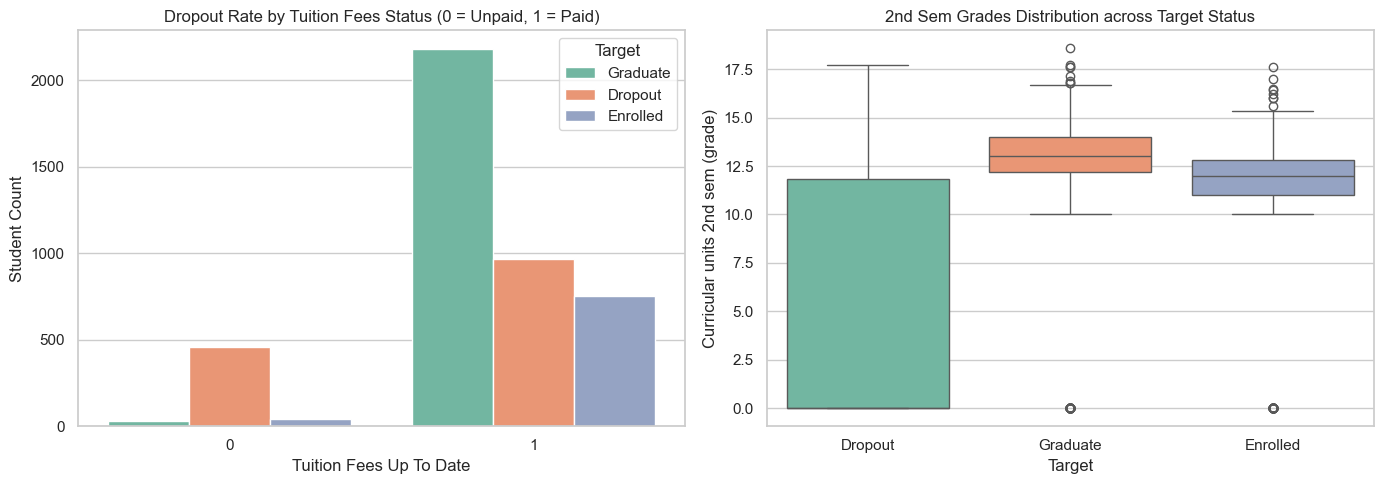

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Tuition fees up to date', hue='Target', palette='Set2', ax=axes[0])
axes[0].set_title('Dropout Rate by Tuition Fees Status (0 = Unpaid, 1 = Paid)')
axes[0].set_xlabel('Tuition Fees Up To Date')
axes[0].set_ylabel('Student Count')

sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)', hue='Target' ,palette='Set2', ax=axes[1])
axes[1].set_title('2nd Sem Grades Distribution across Target Status')

plt.tight_layout()
plt.show()

In [11]:

df['Target_Binary'] = df['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})


print("Target Class Breakdown:")
print(df['Target_Binary'].value_counts())

df_prepared = df.drop(columns=['Target'])

Target Class Breakdown:
Target_Binary
0    3003
1    1421
Name: count, dtype: int64


C:\Users\furqa\AppData\Local\Temp\ipykernel_11068\2967634647.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


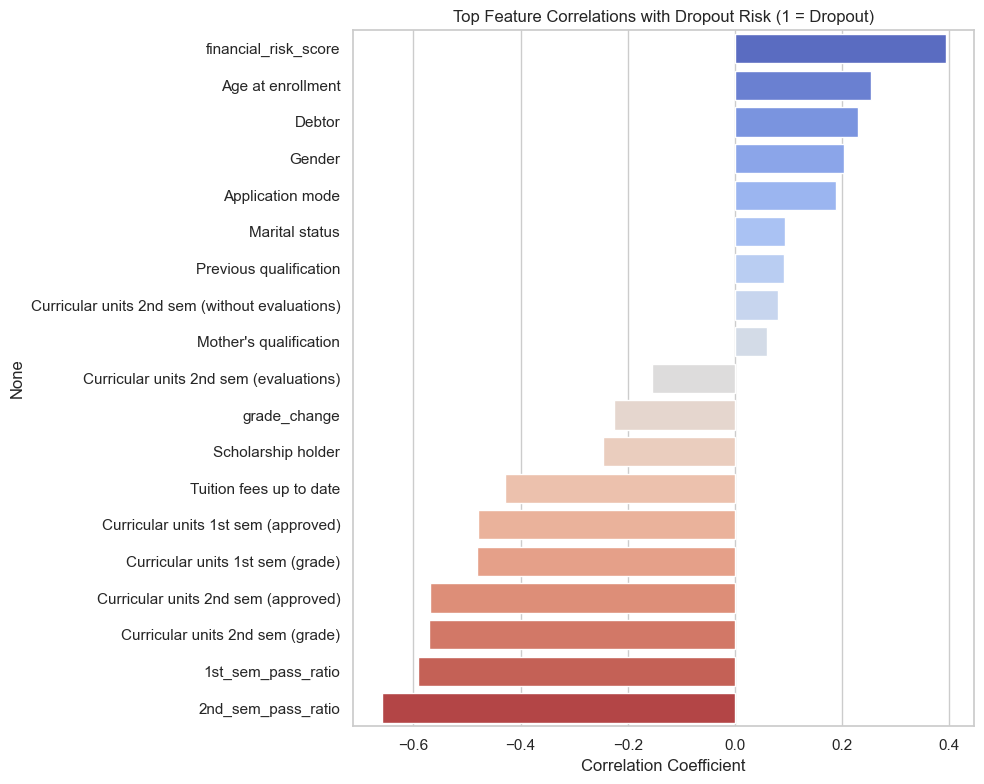

In [19]:
plt.figure(figsize=(10, 8))

correlations = df_prepared.corr()['Target_Binary'].sort_values(ascending=False)

top_corr = pd.concat([correlations.head(10), correlations.tail(10)])
top_corr = top_corr[top_corr.index != 'Target_Binary']

sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Top Feature Correlations with Dropout Risk (1 = Dropout)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [13]:
cleaned_file_path = 'cleaned_dataset.csv'
df_prepared.to_csv(cleaned_file_path, index=False)